# Assignment 4 — Tree & Graph Visualization
**Student ID:** A4_2023xxx  
**GitHub Pages Link:** *(paste your GitHub Pages link here after deployment)*

---

## 📦 Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install networkx matplotlib plotly

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')
print(f'  NetworkX  : {nx.__version__}')
print(f'  Matplotlib: {plt.matplotlib.__version__}')
import plotly
print(f'  Plotly    : {plotly.__version__}')

✅ All libraries imported successfully!
  NetworkX  : 3.6.1
  Matplotlib: 3.10.8
  Plotly    : 6.7.0


---
# 🌳 PART 1 — Tree Dataset

## Dataset Description

| Field | Details |
|---|---|
| **Dataset Name** | World Biome & Species Taxonomy |
| **Source** | Custom synthetic dataset inspired by biological classification (Kingdom → Phylum → Class → Species) |
| **Structure** | Directed tree (hierarchical, no cycles) |
| **Nodes** | Represent biological categories: the root is *Life*, then split into kingdoms, phyla, classes, and example species |
| **Edges** | Directed parent → child relationship meaning "is a parent taxon of" (e.g., *Animalia → Chordata* means Chordata belongs under Animalia) |
| **Why tree?** | Taxonomy is inherently hierarchical — every node has exactly one parent (except the root), which is the defining property of a tree |

In [2]:
# ─── Build the Taxonomy Tree ───────────────────────────────────────────────
T = nx.DiGraph()

edges_tree = [
    # Root → Kingdom
    ("Life", "Animalia"),
    ("Life", "Plantae"),
    ("Life", "Fungi"),

    # Animalia → Phylum
    ("Animalia", "Chordata"),
    ("Animalia", "Arthropoda"),
    ("Animalia", "Mollusca"),

    # Chordata → Class
    ("Chordata", "Mammalia"),
    ("Chordata", "Aves"),
    ("Chordata", "Reptilia"),

    # Arthropoda → Class
    ("Arthropoda", "Insecta"),
    ("Arthropoda", "Arachnida"),

    # Plantae → Phylum
    ("Plantae", "Angiospermae"),
    ("Plantae", "Gymnospermae"),

    # Fungi → Class
    ("Fungi", "Basidiomycota"),
    ("Fungi", "Ascomycota"),

    # Species (leaf nodes)
    ("Mammalia", "Lion"),
    ("Mammalia", "Whale"),
    ("Mammalia", "Human"),
    ("Aves", "Eagle"),
    ("Aves", "Penguin"),
    ("Reptilia", "Crocodile"),
    ("Insecta", "Butterfly"),
    ("Insecta", "Bee"),
    ("Arachnida", "Spider"),
    ("Angiospermae", "Rose"),
    ("Angiospermae", "Mango"),
    ("Gymnospermae", "Pine"),
    ("Basidiomycota", "Mushroom"),
    ("Ascomycota", "Yeast"),
    ("Mollusca", "Octopus"),
    ("Mollusca", "Snail"),
]

T.add_edges_from(edges_tree)

print(f'Tree nodes : {T.number_of_nodes()}')
print(f'Tree edges : {T.number_of_edges()}')
print(f'Is a DAG   : {nx.is_directed_acyclic_graph(T)}')
print(f'Root node  : Life')

Tree nodes : 32
Tree edges : 31
Is a DAG   : True
Root node  : Life


In [3]:
# ─── Helper: Hierarchical Layout (top-down) ────────────────────────────────
def hierarchy_pos(G, root, width=6.0, vert_gap=1.5, vert_loc=0, xcenter=0.5):
    """
    Compute (x, y) positions for a tree rooted at `root`.
    Produces a clean top-down hierarchy layout.
    """
    def _hierarchy_pos(G, root, width, vert_gap, vert_loc, xcenter, pos, parent=None, parsed=None):
        if parsed is None:
            parsed = []
        if root not in parsed:
            parsed.append(root)
            neighbors = list(G.successors(root))
            if parent is not None:
                neighbors = [n for n in neighbors if n != parent]
            if len(neighbors) != 0:
                dx = width / len(neighbors)
                nextx = xcenter - width / 2 - dx / 2
                for neighbor in neighbors:
                    nextx += dx
                    pos = _hierarchy_pos(G, neighbor, width=dx, vert_gap=vert_gap,
                                         vert_loc=vert_loc - vert_gap, xcenter=nextx,
                                         pos=pos, parent=root, parsed=parsed)
            pos[root] = (xcenter, vert_loc)
        return pos
    return _hierarchy_pos(G, root, width=width, vert_gap=vert_gap,
                          vert_loc=vert_loc, xcenter=xcenter, pos={})

print('✅ Hierarchy layout function defined.')

✅ Hierarchy layout function defined.


## 🌳 Tree Layout 1 — Hierarchical (Top-Down)

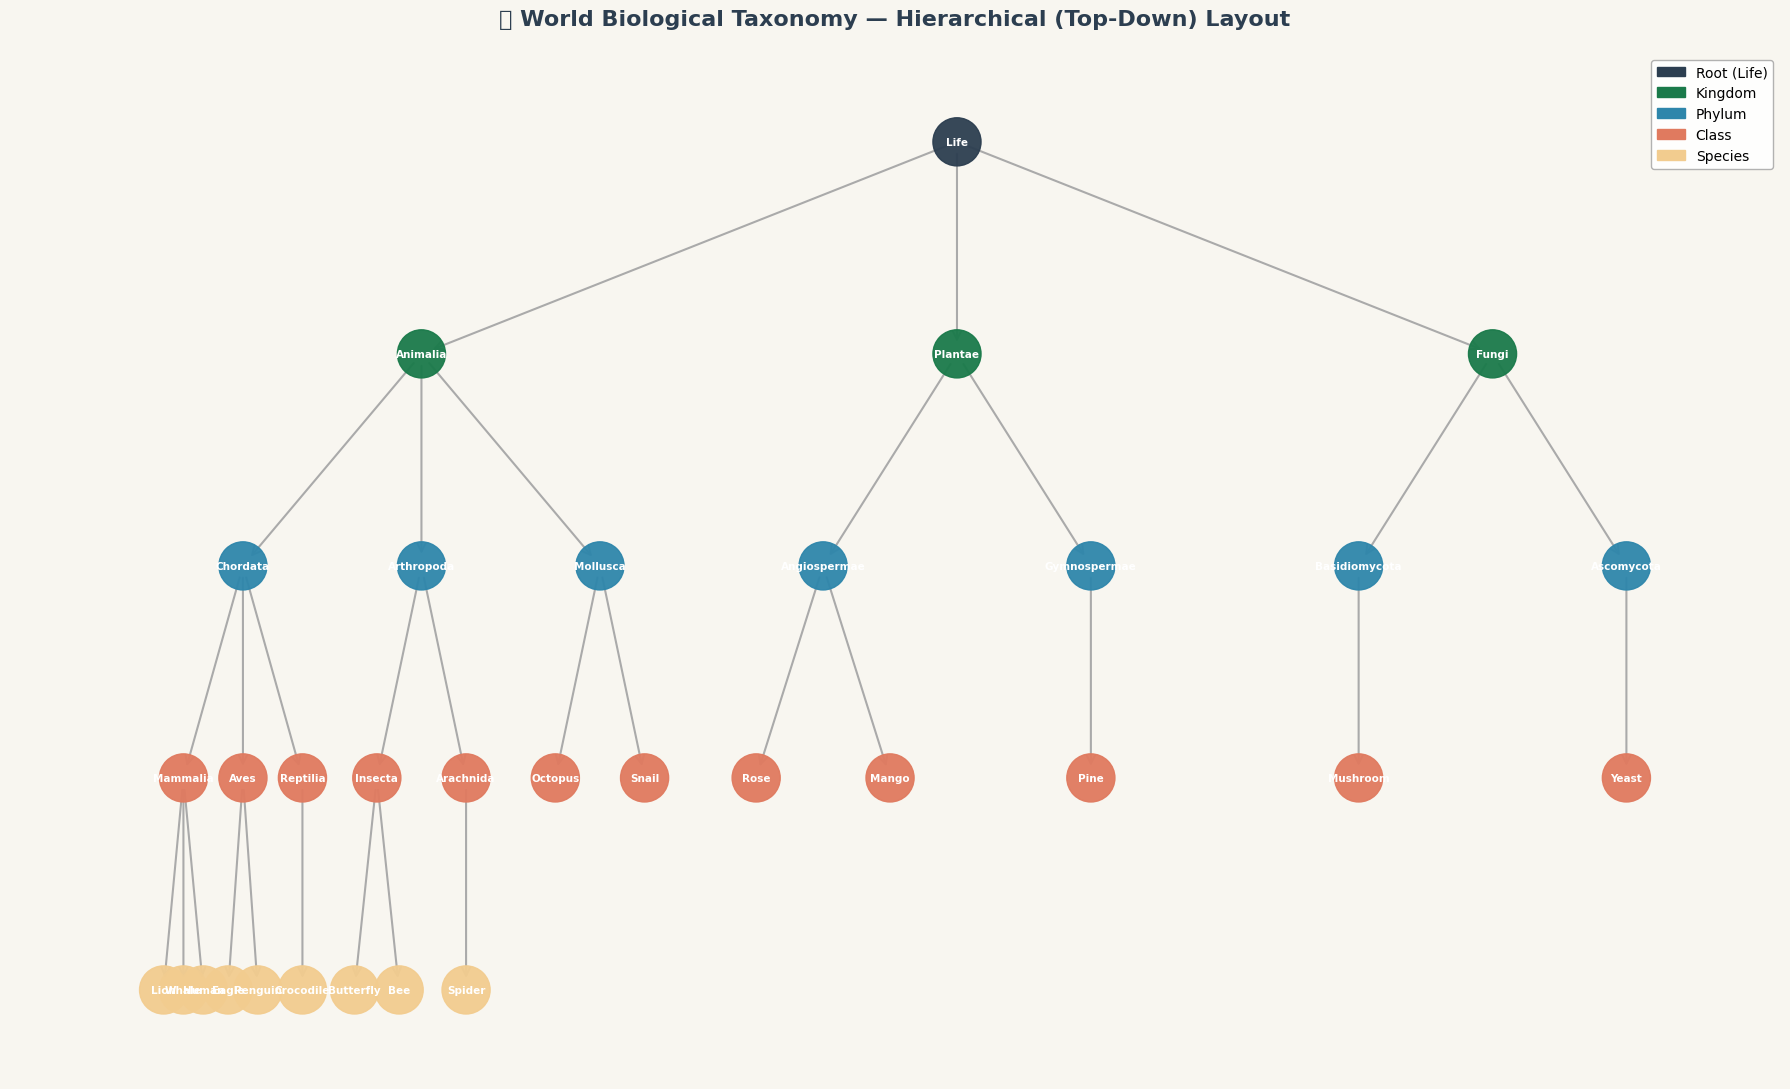

✅ Layout 1 saved as tree_layout1_hierarchical.png


In [4]:
# Node depth for color coding
depth_map = nx.single_source_shortest_path_length(T, "Life")
max_depth = max(depth_map.values())

color_palette = {
    0: '#2C3E50',   # Root     — dark navy
    1: '#1A7A4A',   # Kingdom  — dark green
    2: '#2E86AB',   # Phylum   — blue
    3: '#E07A5F',   # Class    — salmon
    4: '#F2CC8F',   # Species  — light gold
}
node_colors = [color_palette.get(depth_map[n], '#cccccc') for n in T.nodes()]

pos_hier = hierarchy_pos(T, root='Life', width=10.0, vert_gap=1.8)

fig, ax = plt.subplots(figsize=(18, 11))
fig.patch.set_facecolor('#F8F6F0')
ax.set_facecolor('#F8F6F0')

nx.draw_networkx_edges(T, pos_hier, ax=ax,
                       edge_color='#AAAAAA', arrows=True,
                       arrowstyle='->', arrowsize=15,
                       width=1.5, connectionstyle='arc3,rad=0.0')

nx.draw_networkx_nodes(T, pos_hier, ax=ax,
                       node_color=node_colors, node_size=1200, alpha=0.95)

nx.draw_networkx_labels(T, pos_hier, ax=ax,
                        font_size=7.5, font_weight='bold', font_color='white')

# Legend
legend_items = [
    mpatches.Patch(color='#2C3E50', label='Root (Life)'),
    mpatches.Patch(color='#1A7A4A', label='Kingdom'),
    mpatches.Patch(color='#2E86AB', label='Phylum'),
    mpatches.Patch(color='#E07A5F', label='Class'),
    mpatches.Patch(color='#F2CC8F', label='Species'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=10,
          framealpha=0.9, edgecolor='#AAAAAA')

ax.set_title('🌳 World Biological Taxonomy — Hierarchical (Top-Down) Layout',
             fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout1_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Layout 1 saved as tree_layout1_hierarchical.png')

## 🌳 Tree Layout 2 — Radial / Circular Layout

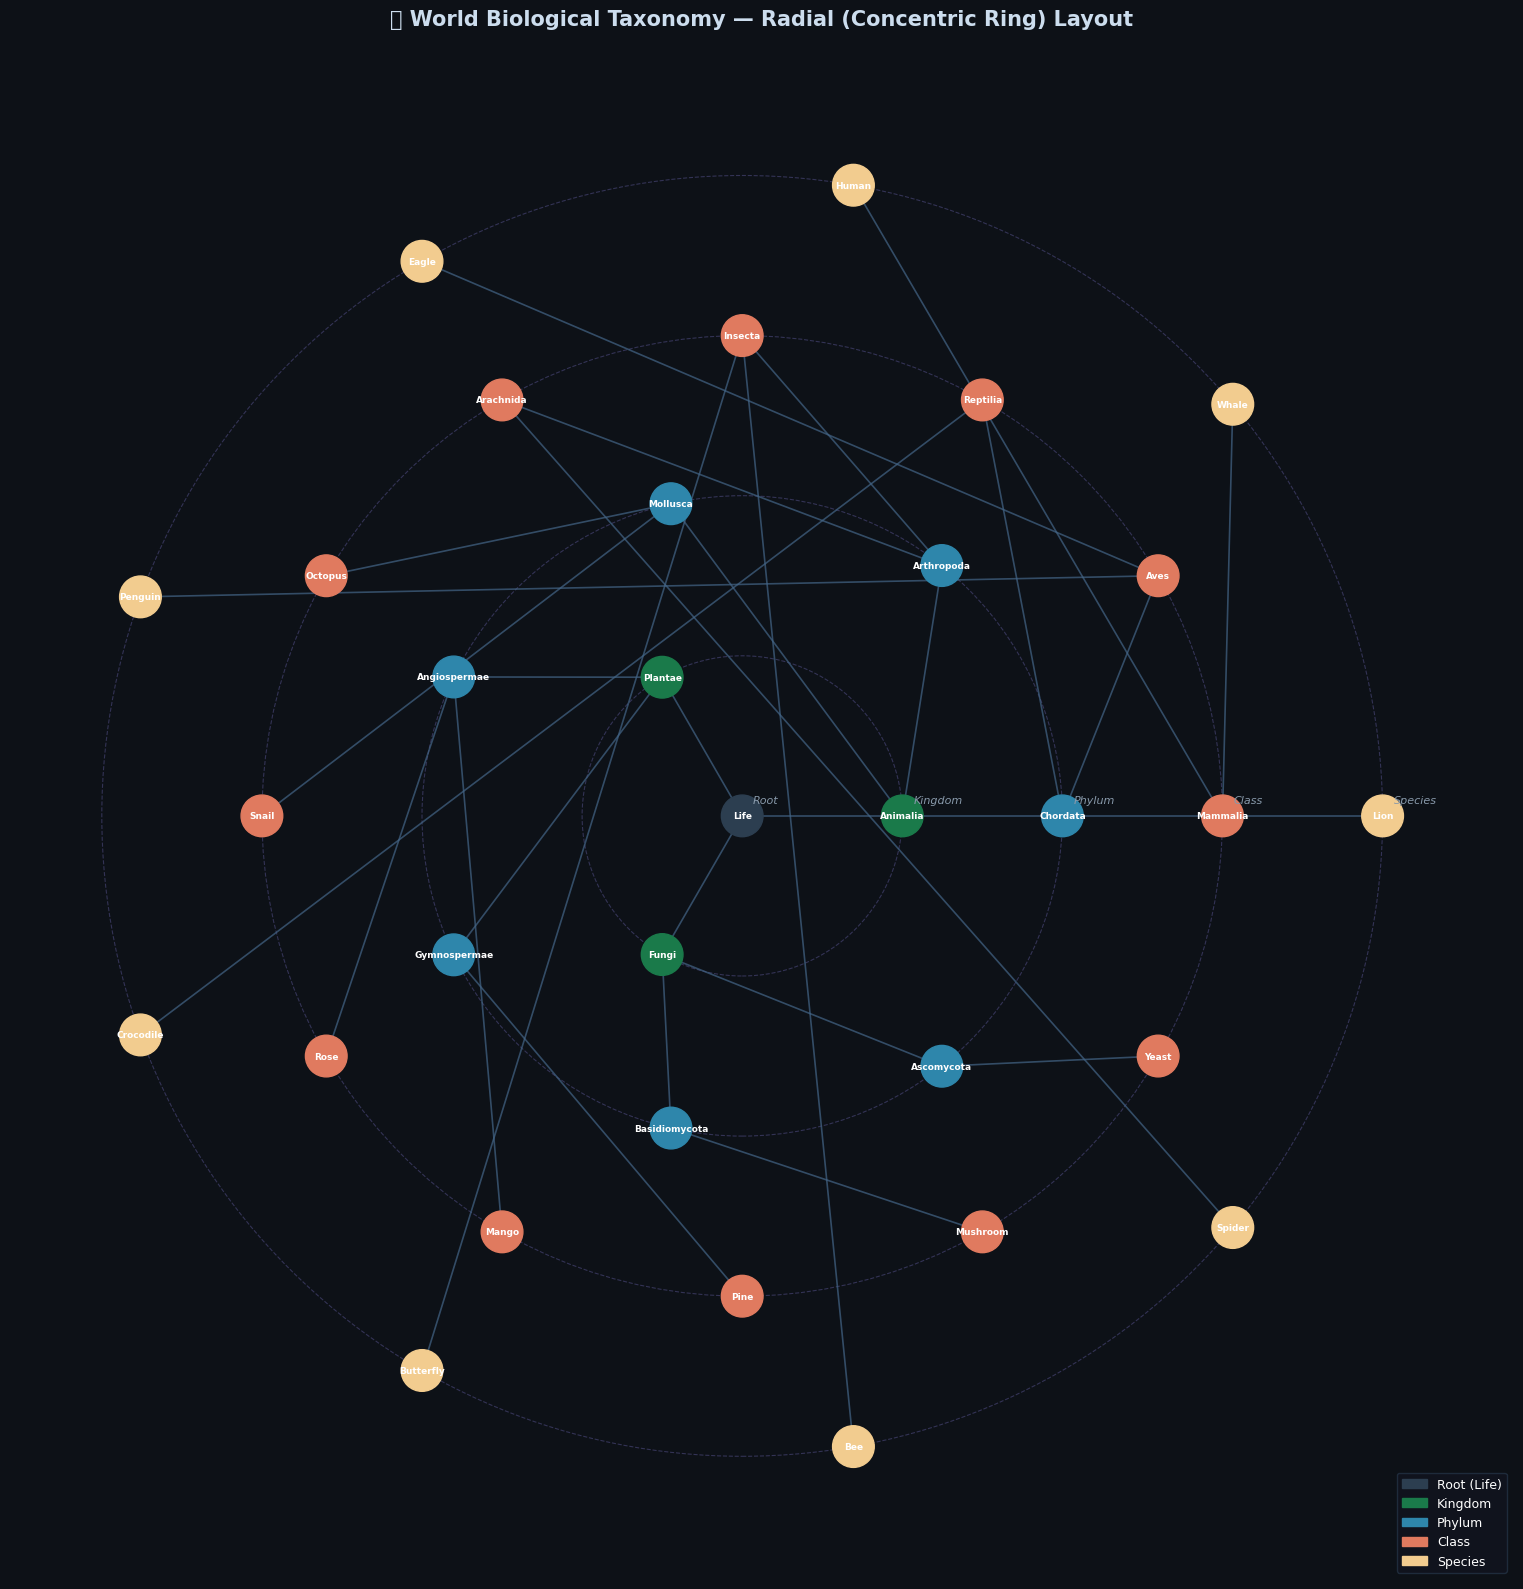

✅ Layout 2 saved as tree_layout2_radial.png


In [5]:
# Radial layout using Plotly for an interactive result
pos_radial = nx.nx_agraph.graphviz_layout(T, prog='twopi', root='Life') \
    if False else nx.spring_layout(T, seed=77, k=2.5, iterations=200)

# Compute radial positions manually
def radial_pos(G, root):
    """Place nodes in concentric rings by depth from root."""
    levels = nx.single_source_shortest_path_length(G, root)
    by_level = {}
    for node, lvl in levels.items():
        by_level.setdefault(lvl, []).append(node)

    pos = {}
    for lvl, nodes in by_level.items():
        r = lvl * 2.2
        for i, node in enumerate(nodes):
            angle = 2 * np.pi * i / max(len(nodes), 1)
            pos[node] = (r * np.cos(angle), r * np.sin(angle))
    return pos

pos_rad = radial_pos(T, 'Life')

fig, ax = plt.subplots(figsize=(16, 16))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Draw concentric rings as reference
for r in [2.2, 4.4, 6.6, 8.8]:
    circle = plt.Circle((0, 0), r, fill=False, color='#333355', linewidth=0.8, linestyle='--')
    ax.add_patch(circle)

nx.draw_networkx_edges(T, pos_rad, ax=ax,
                       edge_color='#446688', arrows=False, width=1.2, alpha=0.7)

nx.draw_networkx_nodes(T, pos_rad, ax=ax,
                       node_color=node_colors, node_size=900, alpha=1.0)

nx.draw_networkx_labels(T, pos_rad, ax=ax,
                        font_size=6.5, font_weight='bold', font_color='white')

# Level annotations
for lvl, label in {0:'Root', 2.2:'Kingdom', 4.4:'Phylum', 6.6:'Class', 8.8:'Species'}.items():
    ax.text(lvl + 0.15, 0.15, label, fontsize=8, color='#8899AA',
            ha='left', va='bottom', style='italic')

ax.legend(handles=legend_items, loc='lower right', fontsize=9,
          framealpha=0.3, edgecolor='#446688', labelcolor='white',
          facecolor='#1A1A2E')

ax.set_title('🌳 World Biological Taxonomy — Radial (Concentric Ring) Layout',
             fontsize=15, fontweight='bold', pad=20, color='#CCDDEE')
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout2_radial.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print('✅ Layout 2 saved as tree_layout2_radial.png')

---
# 🔗 PART 2 — Graph Dataset

## Dataset Description

| Field | Details |
|---|---|
| **Dataset Name** | Les Misérables Character Co-appearance Network |
| **Source** | D. E. Knuth, *The Stanford GraphBase*, 1993. Available in NetworkX as a built-in dataset via `nx.les_miserables_graph()` |
| **Structure** | Undirected weighted graph |
| **Nodes** | 77 characters from Victor Hugo's novel *Les Misérables* |
| **Edges** | An edge exists between two characters if they appear together in the same scene or chapter. Edge **weight** = number of co-appearances |
| **Why graph?** | Unlike a tree, this network has cycles and multiple paths between nodes — characters can share scenes with many others, forming a complex social web with no strict hierarchy |

In [6]:
# ─── Load the Les Misérables graph ─────────────────────────────────────────
G = nx.les_miserables_graph()

print(f'Nodes (characters)  : {G.number_of_nodes()}')
print(f'Edges (co-appearances): {G.number_of_edges()}')
print(f'Is connected        : {nx.is_connected(G)}')
print(f'Average degree      : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}')
print(f'Density             : {nx.density(G):.4f}')

# Compute metrics for visualization
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
communities = nx.community.greedy_modularity_communities(G)

# Assign community colors
community_colors_list = [
    '#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261',
    '#8338EC','#06D6A0','#FB5607','#3A86FF','#FFBE0B',
    '#FF006E','#8ECAE6',
]
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

graph_colors = [community_colors_list[node_community[n] % len(community_colors_list)]
                for n in G.nodes()]

# Node sizes by degree centrality
graph_sizes = [3000 * degree_centrality[n] + 200 for n in G.nodes()]

print(f'\nTop 5 most central characters:')
top5 = sorted(degree_centrality.items(), key=lambda x: -x[1])[:5]
for name, score in top5:
    print(f'  {name:<20} degree centrality = {score:.3f}')

Nodes (characters)  : 77
Edges (co-appearances): 254
Is connected        : True
Average degree      : 6.60
Density             : 0.0868

Top 5 most central characters:
  Valjean              degree centrality = 0.474
  Gavroche             degree centrality = 0.289
  Marius               degree centrality = 0.250
  Javert               degree centrality = 0.224
  Thenardier           degree centrality = 0.211


## 🔗 Graph Layout 1 — Spring (Force-Directed) Layout

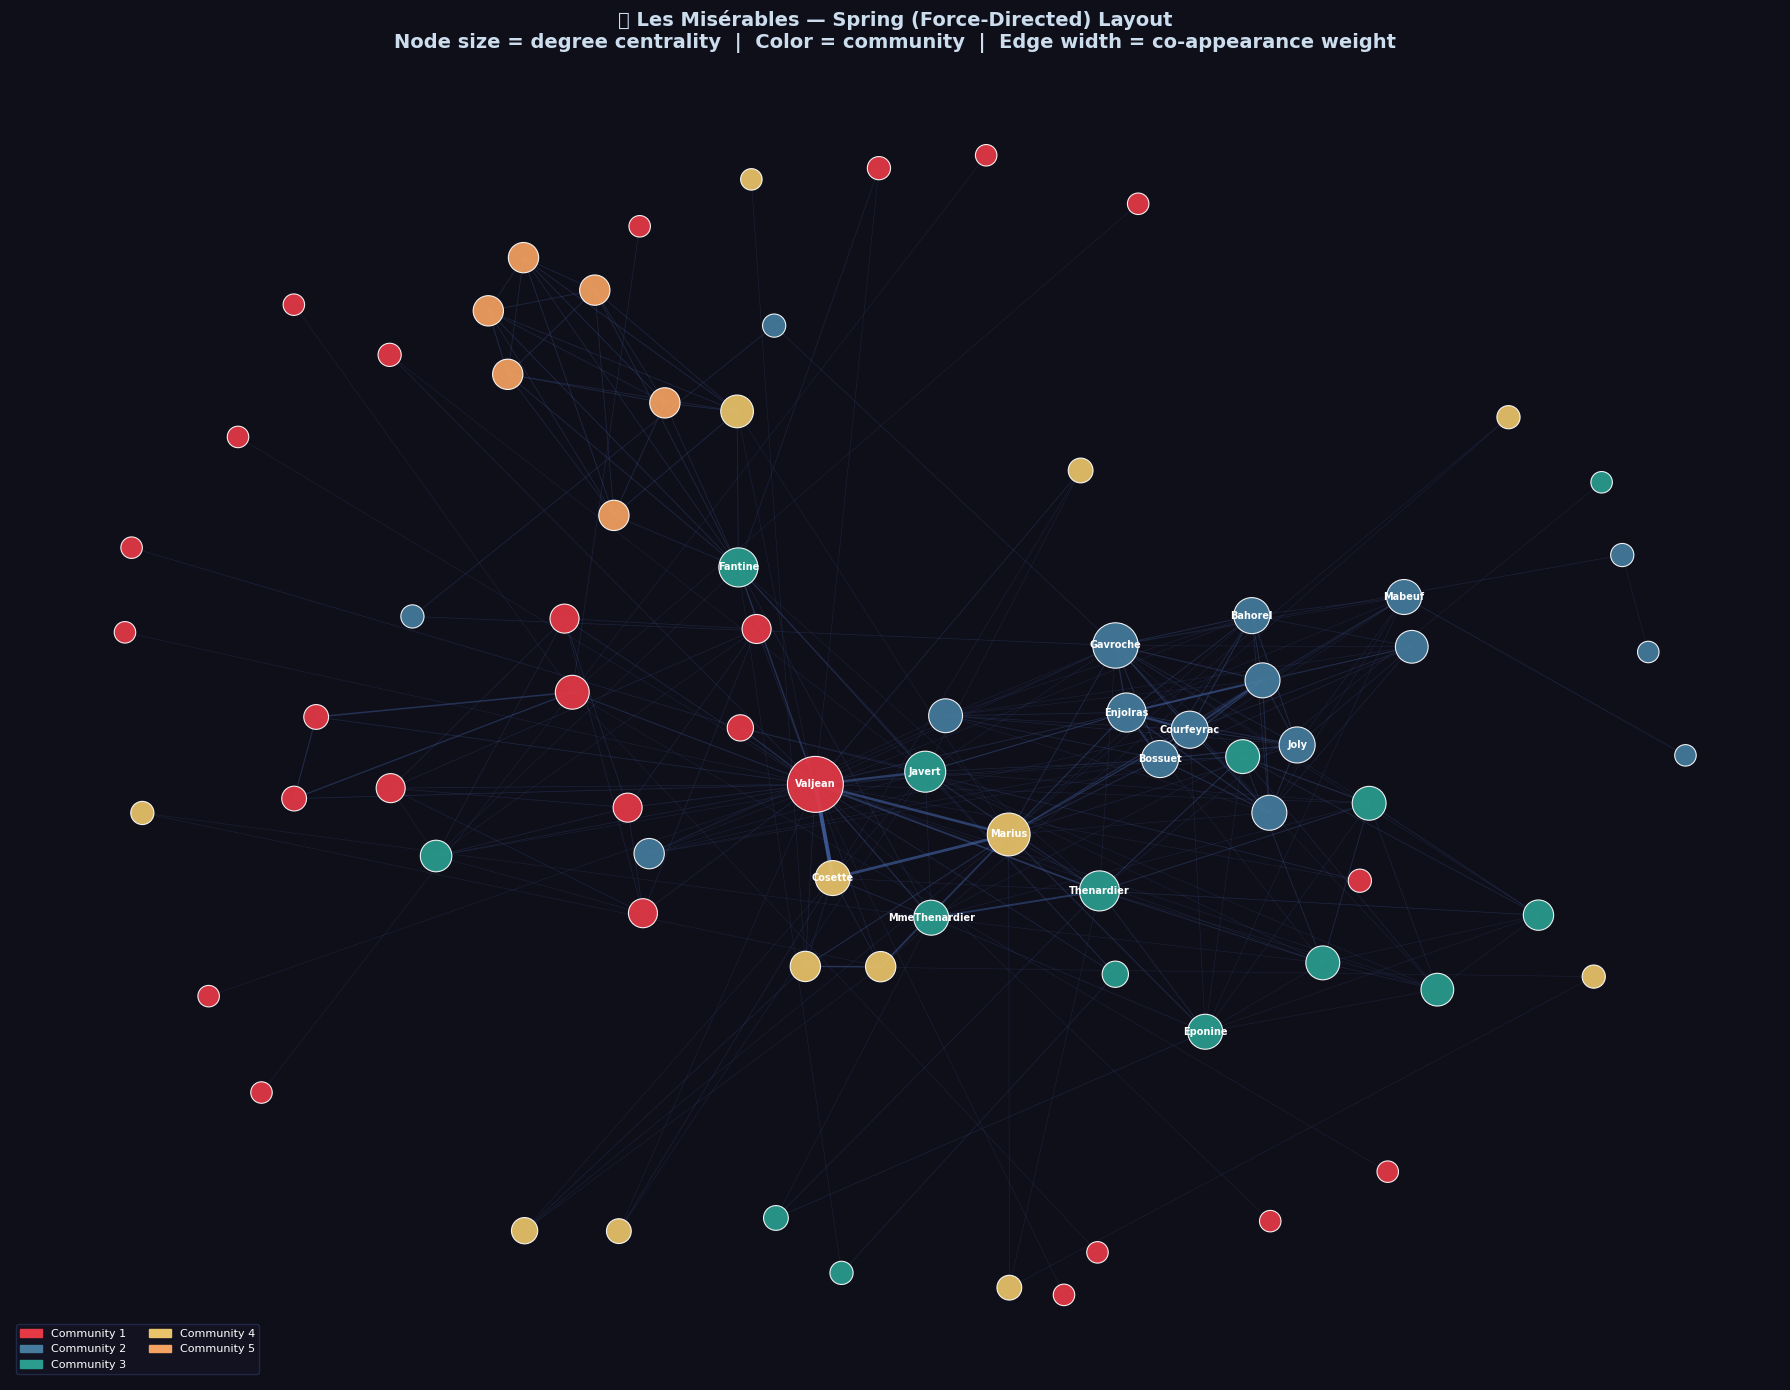

✅ Layout 1 saved as graph_layout1_spring.png


In [7]:
pos_spring = nx.spring_layout(G, seed=42, k=1.8, iterations=100)

fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('#0F0F1A')
ax.set_facecolor('#0F0F1A')

# Edge widths by weight
weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
max_w = max(weights)
edge_widths = [0.3 + 2.5 * (w / max_w) for w in weights]
edge_alphas = [0.2 + 0.6 * (w / max_w) for w in weights]

# Draw edges
for (u, v), width, alpha in zip(G.edges(), edge_widths, edge_alphas):
    nx.draw_networkx_edges(G, pos_spring, edgelist=[(u, v)], ax=ax,
                           edge_color='#4466AA', width=width, alpha=alpha)

# Draw nodes
nx.draw_networkx_nodes(G, pos_spring, ax=ax,
                       node_color=graph_colors, node_size=graph_sizes,
                       alpha=0.92, linewidths=0.8, edgecolors='white')

# Labels only for top-degree nodes
top_nodes = {n for n, _ in sorted(degree_centrality.items(),
                                   key=lambda x: -x[1])[:15]}
labels = {n: n for n in top_nodes}
nx.draw_networkx_labels(G, pos_spring, labels=labels, ax=ax,
                        font_size=7, font_weight='bold', font_color='white')

# Community legend (top communities)
comm_patches = [mpatches.Patch(color=community_colors_list[i % len(community_colors_list)],
                               label=f'Community {i+1}')
                for i in range(min(8, len(communities)))]
ax.legend(handles=comm_patches, loc='lower left', fontsize=8,
          framealpha=0.3, facecolor='#1A1A2E', edgecolor='#4466AA',
          labelcolor='white', ncol=2)

ax.set_title('🔗 Les Misérables — Spring (Force-Directed) Layout\n'
             'Node size = degree centrality  |  Color = community  |  Edge width = co-appearance weight',
             fontsize=14, fontweight='bold', color='#CCDDEE', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_layout1_spring.png', dpi=150, bbox_inches='tight',
            facecolor='#0F0F1A')
plt.show()
print('✅ Layout 1 saved as graph_layout1_spring.png')

## 🔗 Graph Layout 2 — Kamada-Kawai Layout

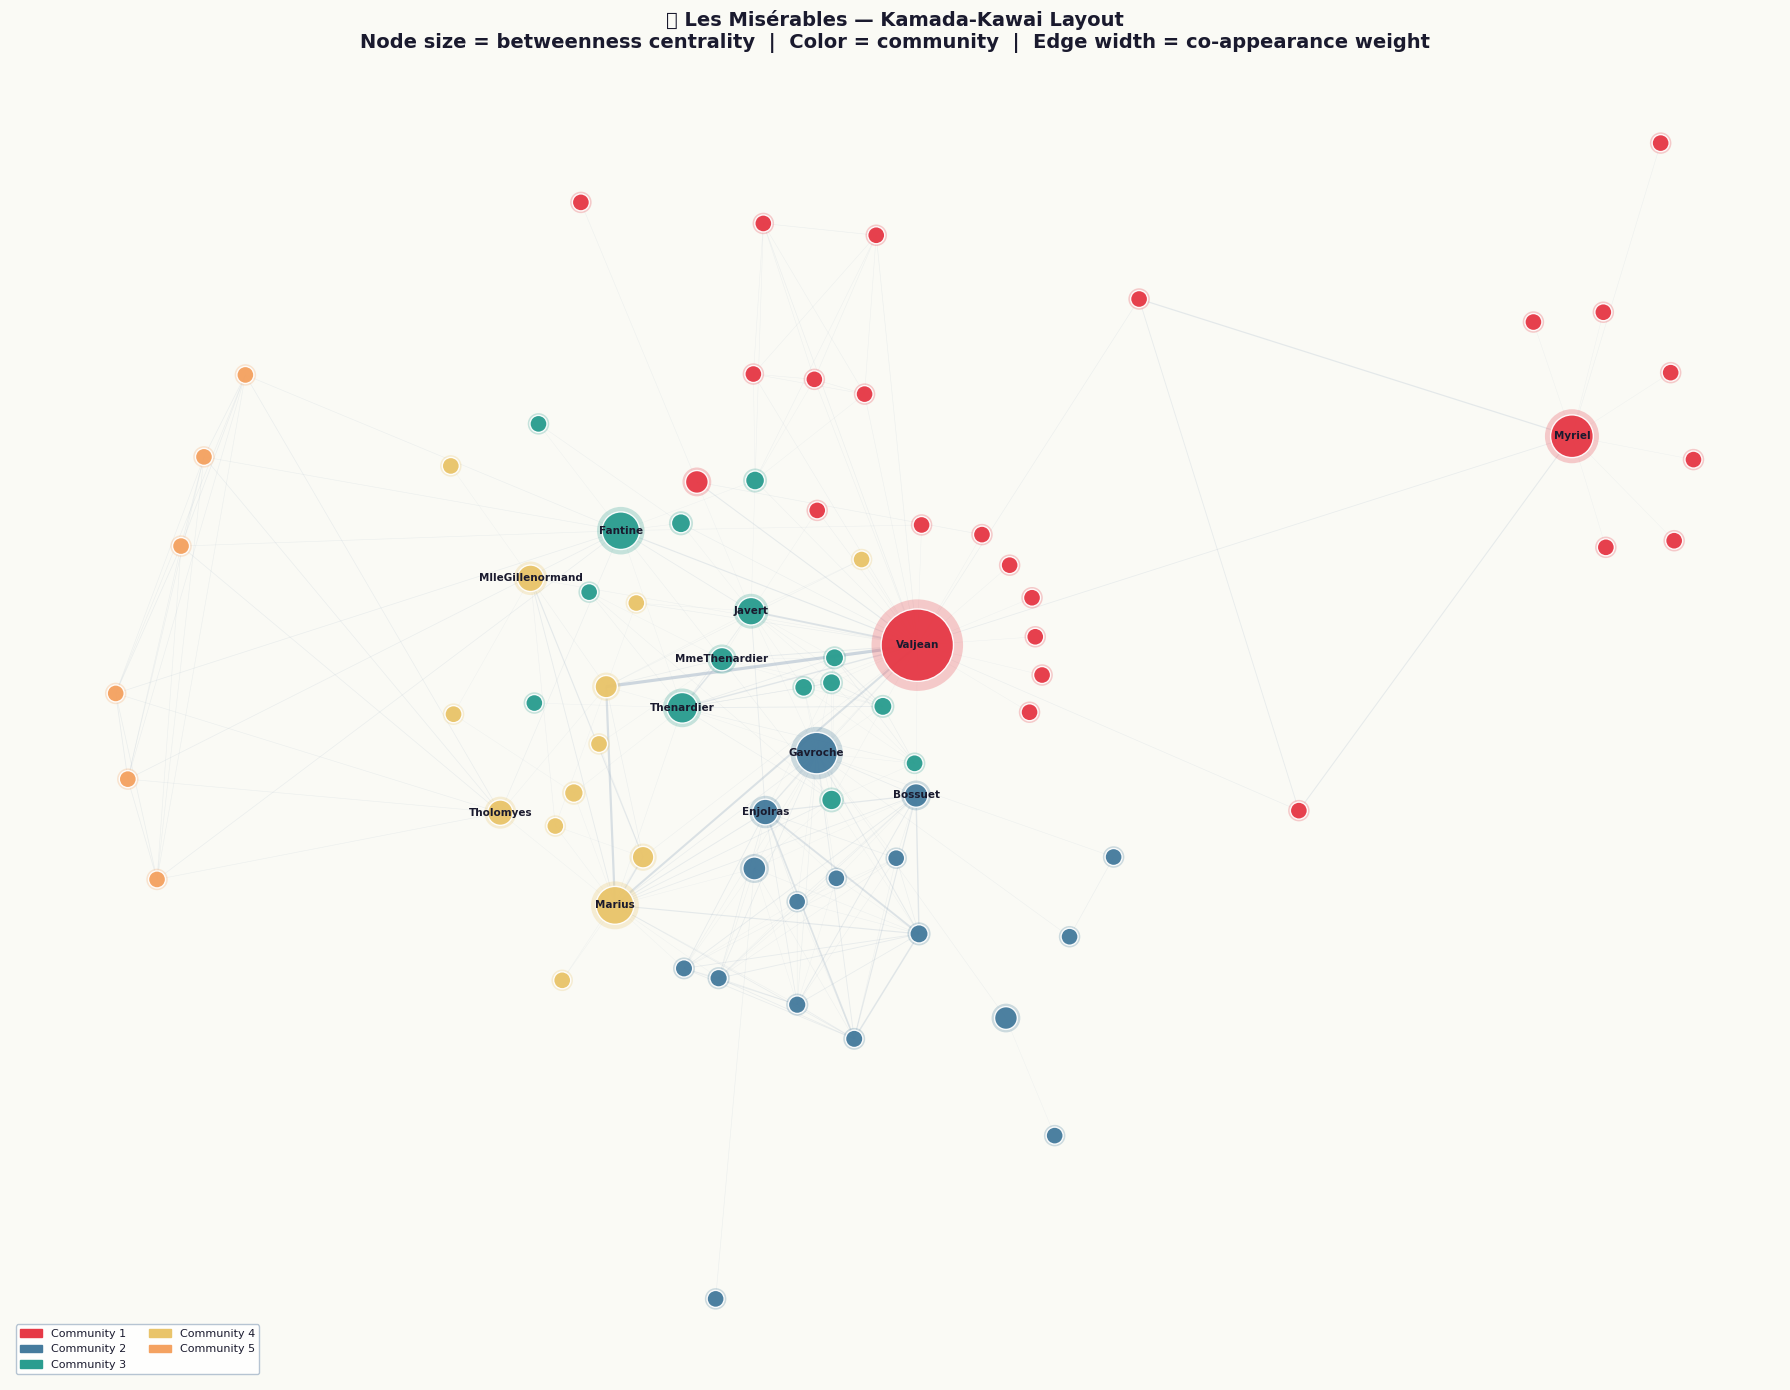

✅ Layout 2 saved as graph_layout2_kamada_kawai.png


In [8]:
pos_kk = nx.kamada_kawai_layout(G)

fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('#FAFAF5')
ax.set_facecolor('#FAFAF5')

# Draw edges with weight-based styling
for (u, v), width, alpha in zip(G.edges(), edge_widths, edge_alphas):
    nx.draw_networkx_edges(G, pos_kk, edgelist=[(u, v)], ax=ax,
                           edge_color='#AABBCC', width=width * 0.8,
                           alpha=alpha * 0.7)

# Draw nodes (betweenness adds glow ring)
bet_sizes = [4500 * betweenness[n] + 150 for n in G.nodes()]
# Outer glow ring
nx.draw_networkx_nodes(G, pos_kk, ax=ax,
                       node_color=graph_colors, node_size=[s * 1.6 for s in bet_sizes],
                       alpha=0.25, linewidths=0)
# Main nodes
nx.draw_networkx_nodes(G, pos_kk, ax=ax,
                       node_color=graph_colors, node_size=bet_sizes,
                       alpha=0.95, linewidths=1.0, edgecolors='white')

# Labels for top betweenness nodes
top_bet = {n for n, _ in sorted(betweenness.items(), key=lambda x: -x[1])[:12]}
labels_bet = {n: n for n in top_bet}
nx.draw_networkx_labels(G, pos_kk, labels=labels_bet, ax=ax,
                        font_size=7.5, font_weight='bold', font_color='#1A1A2E')

ax.legend(handles=comm_patches, loc='lower left', fontsize=8,
          framealpha=0.85, facecolor='white', edgecolor='#AABBCC',
          labelcolor='#1A1A2E', ncol=2)

ax.set_title('🔗 Les Misérables — Kamada-Kawai Layout\n'
             'Node size = betweenness centrality  |  Color = community  |  Edge width = co-appearance weight',
             fontsize=14, fontweight='bold', color='#1A1A2E', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_layout2_kamada_kawai.png', dpi=150, bbox_inches='tight',
            facecolor='#FAFAF5')
plt.show()
print('✅ Layout 2 saved as graph_layout2_kamada_kawai.png')

---
# 📊 Summary

| Section | Dataset | Layout 1 | Layout 2 |
|---|---|---|---|
| **Tree** | World Biological Taxonomy | Hierarchical (Top-Down) | Radial (Concentric Rings) |
| **Graph** | Les Misérables Characters | Spring / Force-Directed | Kamada-Kawai |

### Key Observations

**Tree Visualizations:**
- The **hierarchical layout** clearly shows parent-child depth levels from root (Life) down to individual species.
- The **radial layout** gives a more compact view, with nodes at the same taxonomic level placed at the same ring distance from the centre.

**Graph Visualizations:**
- The **spring layout** uses repulsive/attractive forces to reveal natural clusters (communities) in the network — characters who interact often are pulled together.
- The **Kamada-Kawai layout** minimizes graph-theoretic distances, placing nodes to best reflect the true shortest-path relationships, which highlights bridge characters with high betweenness centrality.

---
*GitHub Pages Link: [paste link here]*